⏳ Extrayendo potencia de bandas por canal...

=== TABLA DE SUBIDAS Y BAJADAS (%) RESPECTO A REPOSO (REST) ===


/var/folders/2_/gw153x4s3m784dgv1llmb_vc0000gn/T/ipykernel_1342/2753886481.py:52: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 250, using nperseg = 250
  freqs, psd = welch(window, fs=FS, axis=0)


                   Canal_1_Theta  Canal_1_Alpha  Canal_1_Beta  Canal_1_Gamma  \
activity                                                                       
BRAWL_STARS                 6.03           7.86          5.69           7.97   
DEMOSTRACIONLUZMA           0.00           0.00          0.00           0.00   
DIBUJANDO                  -3.24          -0.81          0.08          -0.45   
MATH_LOAD                 124.64          29.86         33.31          47.45   
SUBWAY_SURFERS             14.08          17.92         18.61          44.93   

                   Canal_2_Theta  Canal_2_Alpha  Canal_2_Beta  Canal_2_Gamma  
activity                                                                      
BRAWL_STARS               210.91         166.31         80.42          41.45  
DEMOSTRACIONLUZMA           0.00           0.00          0.00           0.00  
DIBUJANDO                  31.01          33.38         -2.36          15.84  
MATH_LOAD                1101.43         125

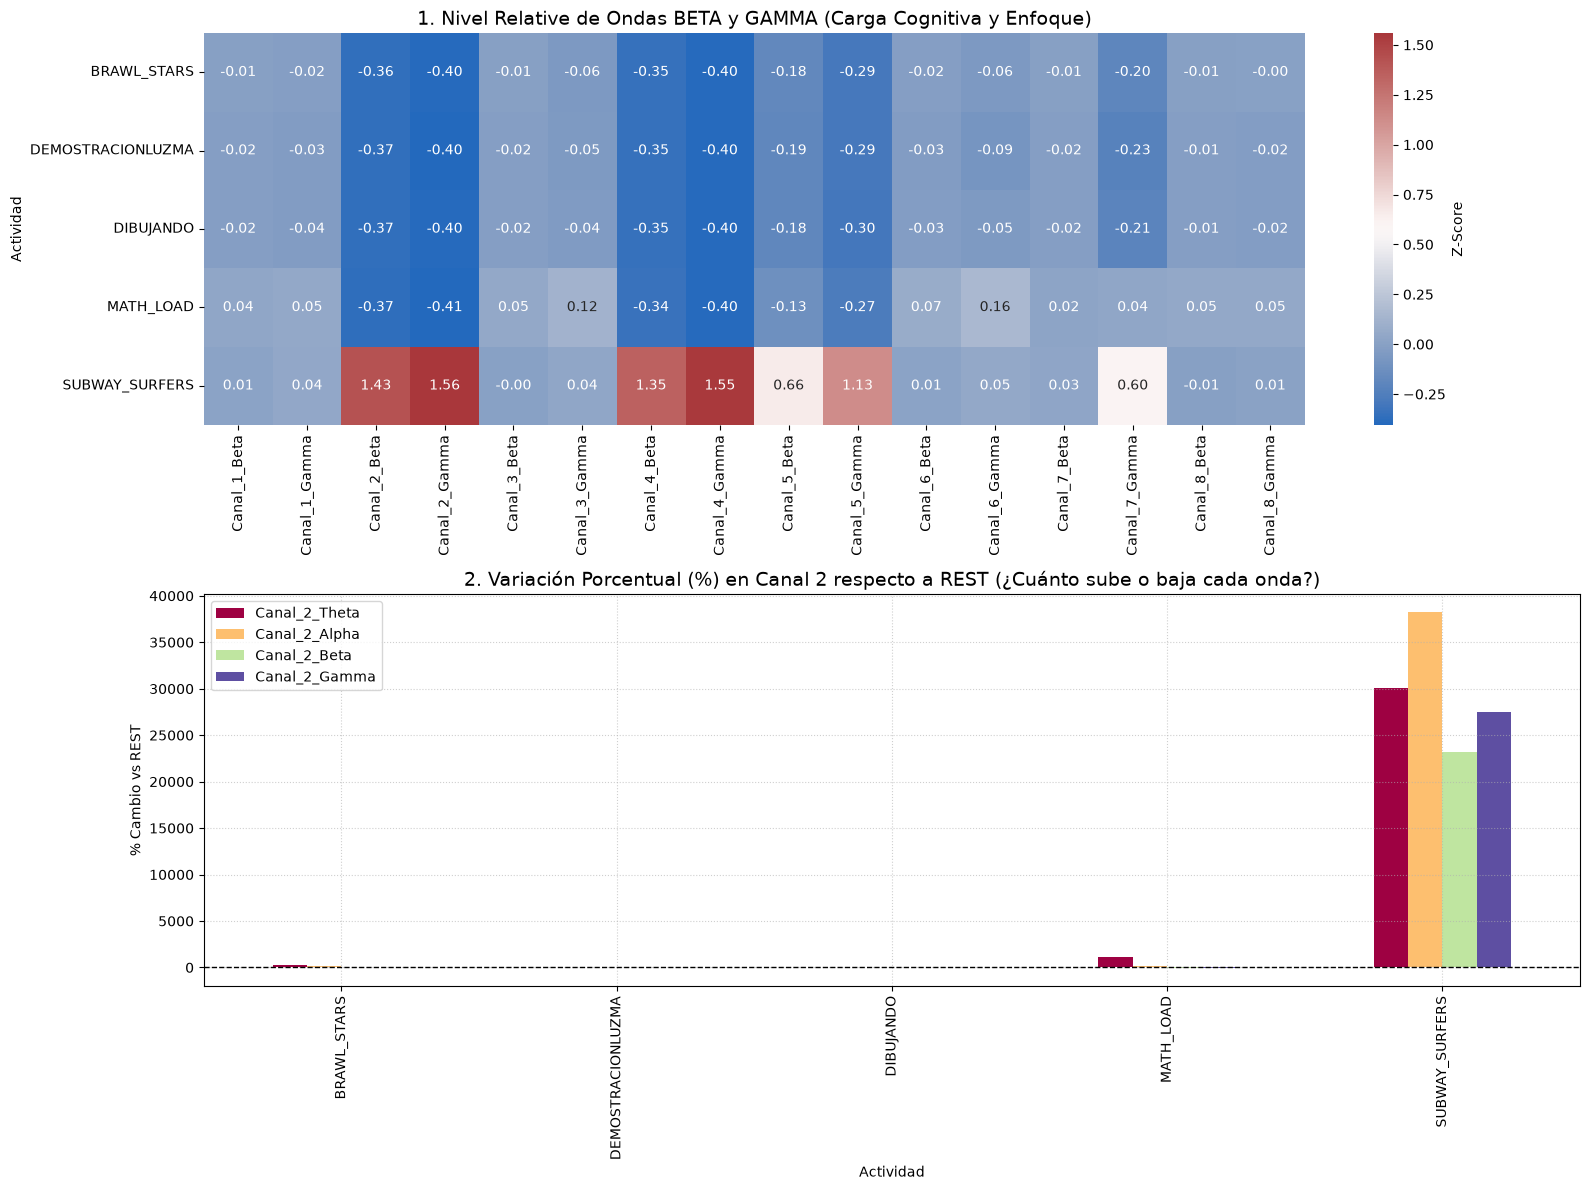

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch, butter, filtfilt
from sklearn.preprocessing import StandardScaler

# --- 1. RUTAS DE LOS 5 DATASETS ---
paths = {
    'BRAWL_STARS':     '/Users/yaelhernandez/Downloads/Hackathonpariguas/datos_brawlstars.csv',
    'DEMOSTRACIONLUZMA':            '/Users/yaelhernandez/Downloads/Hackathonpariguas/datos_demostracionluzma.csv',
    'DIBUJANDO':       '/Users/yaelhernandez/Downloads/Hackathonpariguas/datos_dibujando(movimiento).csv',
    'SUBWAY_SURFERS':  '/Users/yaelhernandez/Downloads/Hackathonpariguas/datos_subway.csv',
    'MATH_LOAD':       '/Users/yaelhernandez/Downloads/Hackathonpariguas/datos_fraccionesfarciales.csv'
}

FS = 250
BANDS = {
    'Theta': (4, 8),
    'Alpha': (8, 12),
    'Beta':  (12, 30),
    'Gamma': (30, 45)
}

def apply_bandpass(data, lowcut=1.0, highcut=40.0, fs=FS):
    nyq = 0.5 * fs
    b, a = butter(4, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, data, axis=0)

# --- 2. EXTRACCIÓN DE POTENCIAS EN VALORES REALES (RAW) ---
def extract_eeg_features(paths_dict):
    all_rows = []
    sample_df = pd.read_csv(list(paths_dict.values())[0])
    cols_ignore = ['Tiempo_s', 'Timestamp', 'Counter', 'Validation', 'activity', 'AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY', 'GyroZ']
    eeg_channels = [c for c in sample_df.columns if c not in cols_ignore][:8]

    for label, path in paths_dict.items():
        df = pd.read_csv(path)
        df_eeg = df[[c for c in df.columns if c in eeg_channels or c.startswith('Canal_')]].iloc[:, :8]
        df_eeg.columns = eeg_channels
        
        filtered = apply_bandpass(df_eeg.values)
        num_samples = len(filtered)
        win_size = min(250, num_samples)
        step_size = max(5, int((num_samples - win_size) / 30)) if num_samples > win_size else 5

        for start in range(0, num_samples - win_size + 1, step_size):
            end = start + win_size
            window = filtered[start:end, :]
            
            row = {'activity': label}
            freqs, psd = welch(window, fs=FS, axis=0)
            
            for ch_idx, ch_name in enumerate(eeg_channels):
                psd_ch = psd[:, ch_idx]
                for band_name, (fmin, fmax) in BANDS.items():
                    mask = (freqs >= fmin) & (freqs <= fmax)
                    row[f'{ch_name}_{band_name}'] = np.sum(psd_ch[mask])
                    
            all_rows.append(row)
            
    return pd.DataFrame(all_rows), eeg_channels

print("⏳ Extrayendo potencia de bandas por canal...")
df_raw, eeg_channels = extract_eeg_features(paths)

# --- 3. PROMEDIO DE POTENCIA POR ACTIVIDAD ---
mean_powers = df_raw.groupby('activity').mean(numeric_only=True)

# --- 4. CÁLCULO DE SUBIDAS Y BAJADAS (% DE CAMBIO RESPECTO A REST) ---
rest_baseline = mean_powers.loc['DEMOSTRACIONLUZMA']
pct_change_vs_rest = ((mean_powers - rest_baseline) / rest_baseline) * 100

print("\n=== TABLA DE SUBIDAS Y BAJADAS (%) RESPECTO A REPOSO (REST) ===")
# Muestra un resumen de los primeros dos canales
cols_preview = [c for c in pct_change_vs_rest.columns if 'Canal_1' in c or 'Canal_2' in c]
print(pct_change_vs_rest[cols_preview].round(2))

# --- 5. NORMALIZACIÓN AL FINAL (Z-SCORE SOLO PARA VISUALIZACIÓN PAREJA) ---
X = df_raw.drop(columns=['activity'])
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
df_scaled['activity'] = df_raw['activity'].values
mean_scaled = df_scaled.groupby('activity').mean()

# --- 6. GRÁFICAS COMPARATIVAS DE COMPORTAMIENTO ---
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Gráfica 1: Comportamiento de Beta y Gamma en MATH_LOAD vs el resto (Z-score)
cols_beta_gamma = [c for c in mean_scaled.columns if 'Beta' in c or 'Gamma' in c]
sns.heatmap(mean_scaled[cols_beta_gamma], ax=axes[0], cmap='vlag', annot=True, fmt=".2f", cbar_kws={'label': 'Z-Score'})
axes[0].set_title("1. Nivel Relative de Ondas BETA y GAMMA (Carga Cognitiva y Enfoque)", fontsize=14)
axes[0].set_ylabel("Actividad")

# Gráfica 2: Porcentaje de incremento/decremento directo respecto a REST en Canal 2
cols_ch2 = [c for c in pct_change_vs_rest.columns if 'Canal_2' in c]
pct_change_vs_rest[cols_ch2].plot(kind='bar', ax=axes[1], colormap='Spectral')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title("2. Variación Porcentual (%) en Canal 2 respecto a REST (¿Cuánto sube o baja cada onda?)", fontsize=14)
axes[1].set_ylabel("% Cambio vs REST")
axes[1].set_xlabel("Actividad")
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

/var/folders/2_/gw153x4s3m784dgv1llmb_vc0000gn/T/ipykernel_1342/2187484331.py:47: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 250, using nperseg = 250
  freqs, psd = welch(window, fs=FS, axis=0)


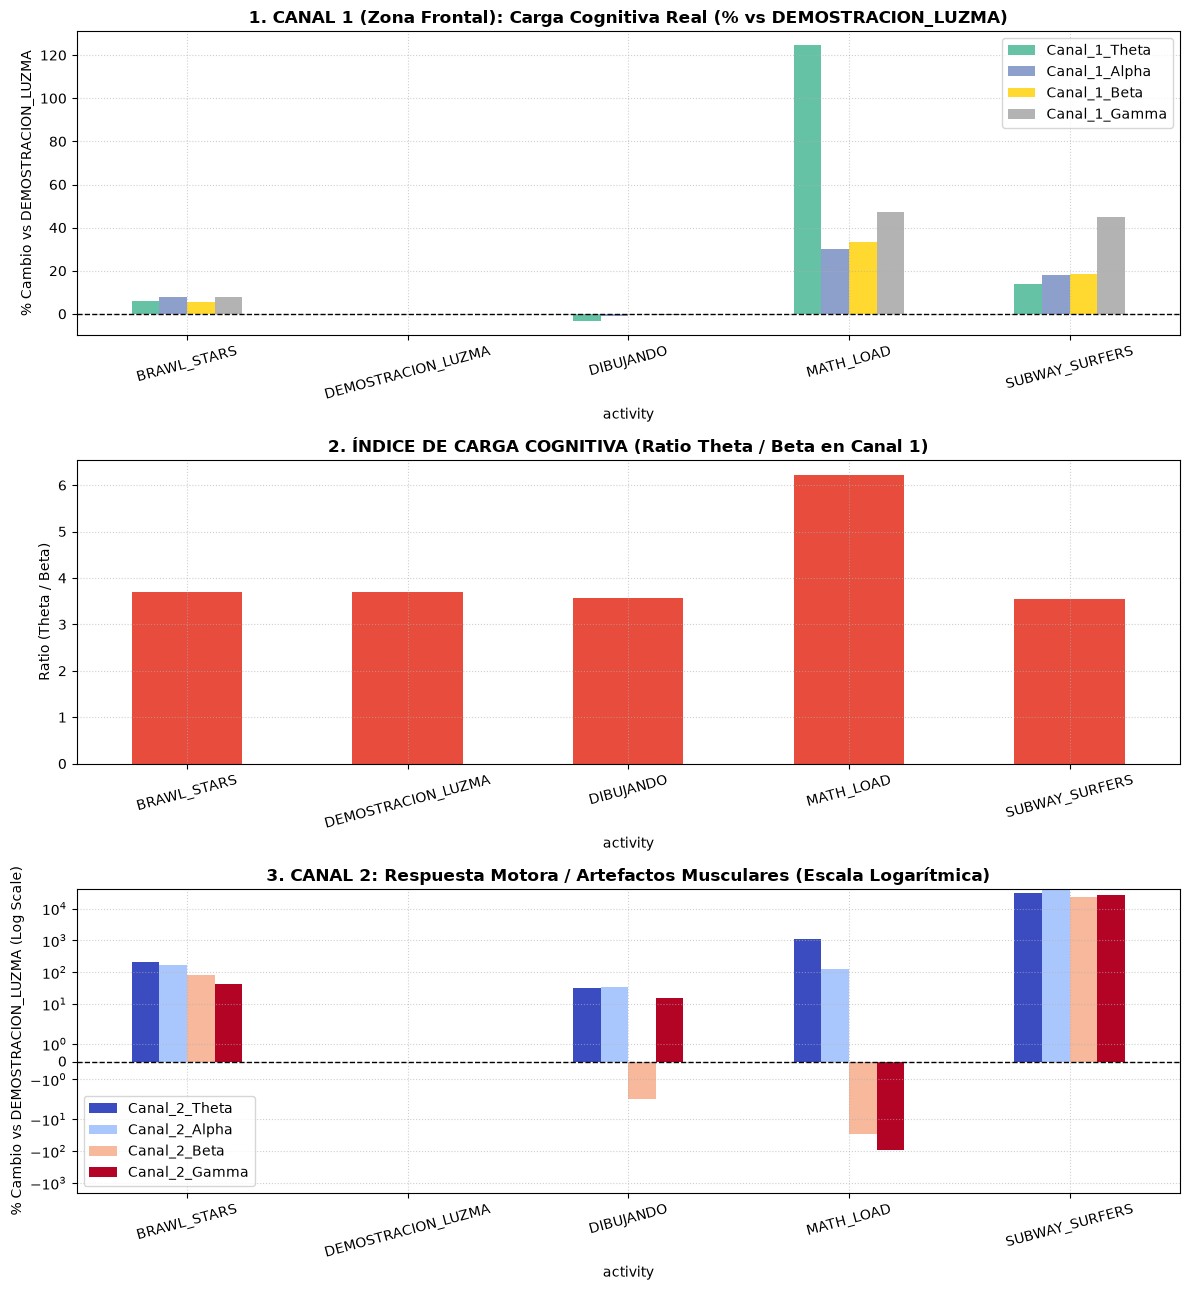

In [24]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch, butter, filtfilt

# --- 1. RUTAS DE LOS DATASETS (Rutas Relativas + Etiqueta Corregida) ---
BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else '.'

paths = {
    'BRAWL_STARS':        os.path.join(BASE_DIR, 'datos_brawlstars.csv'),
    'DEMOSTRACION_LUZMA': os.path.join(BASE_DIR, 'datos_demostracionluzma.csv'), # <-- CAMBIO 1
    'DIBUJANDO':          os.path.join(BASE_DIR, 'datos_dibujando(movimiento).csv'),
    'SUBWAY_SURFERS':     os.path.join(BASE_DIR, 'datos_subway.csv'),
    'MATH_LOAD':          os.path.join(BASE_DIR, 'datos_fraccionesfarciales.csv')
}

FS = 250
BANDS = {'Theta': (4, 8), 'Alpha': (8, 12), 'Beta': (12, 30), 'Gamma': (30, 45)}

def apply_bandpass(data, lowcut=1.0, highcut=40.0, fs=FS):
    nyq = 0.5 * fs
    b, a = butter(4, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, data, axis=0)

# --- 2. EXTRACCIÓN DE POTENCIA ---
all_rows = []
sample_df = pd.read_csv(list(paths.values())[0])
cols_ignore = ['Tiempo_s', 'Timestamp', 'Counter', 'Validation', 'activity', 'AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY', 'GyroZ']
eeg_channels = [c for c in sample_df.columns if c not in cols_ignore][:8]

for label, path in paths.items():
    df = pd.read_csv(path)
    df_eeg = df[[c for c in df.columns if c in eeg_channels or c.startswith('Canal_')]].iloc[:, :8]
    df_eeg.columns = eeg_channels
    filtered = apply_bandpass(df_eeg.values)
    
    num_samples = len(filtered)
    win_size = min(250, num_samples)
    step_size = max(5, int((num_samples - win_size) / 30)) if num_samples > win_size else 5

    for start in range(0, num_samples - win_size + 1, step_size):
        end = start + win_size
        window = filtered[start:end, :]
        row = {'activity': label}
        freqs, psd = welch(window, fs=FS, axis=0)
        
        for ch_idx, ch_name in enumerate(eeg_channels):
            psd_ch = psd[:, ch_idx]
            for band_name, (fmin, fmax) in BANDS.items():
                mask = (freqs >= fmin) & (freqs <= fmax)
                row[f'{ch_name}_{band_name}'] = np.sum(psd_ch[mask])
        all_rows.append(row)

df_raw = pd.DataFrame(all_rows)
mean_powers = df_raw.groupby('activity').mean(numeric_only=True)

# Porcentaje de cambio vs DEMOSTRACION_LUZMA
luzma_baseline = mean_powers.loc['DEMOSTRACION_LUZMA'] # <-- CAMBIO 2
pct_change = ((mean_powers - luzma_baseline) / luzma_baseline) * 100

# Índice de Carga Cognitiva (Theta / Beta) en Canal 1
mean_powers['Ratio_Theta_Beta_C1'] = mean_powers['Canal_1_Theta'] / mean_powers['Canal_1_Beta']

# --- 3. GRÁFICAS CORREGIDAS (Etiquetas actualizadas) ---
fig, axes = plt.subplots(3, 1, figsize=(12, 13))

# Gráfica 1: Canal 1 Limpio
cols_c1 = [c for c in pct_change.columns if 'Canal_1' in c]
pct_change[cols_c1].plot(kind='bar', ax=axes[0], colormap='Set2')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title("1. CANAL 1 (Zona Frontal): Carga Cognitiva Real (% vs DEMOSTRACION_LUZMA)", fontsize=12, fontweight='bold') # <-- CAMBIO 3
axes[0].set_ylabel("% Cambio vs DEMOSTRACION_LUZMA") # <-- CAMBIO 3
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].tick_params(axis='x', rotation=15)

# Gráfica 2: Índice de Carga Cognitiva (Theta / Beta)
mean_powers['Ratio_Theta_Beta_C1'].plot(kind='bar', ax=axes[1], color='#e74c3c')
axes[1].set_title("2. ÍNDICE DE CARGA COGNITIVA (Ratio Theta / Beta en Canal 1)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Ratio (Theta / Beta)")
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].tick_params(axis='x', rotation=15)

# Gráfica 3: Canal 2 con Escala Logarítmica
cols_c2 = [c for c in pct_change.columns if 'Canal_2' in c]
pct_change[cols_c2].plot(kind='bar', ax=axes[2], colormap='coolwarm')
axes[2].set_yscale('symlog')
axes[2].axhline(0, color='black', linestyle='--', linewidth=1)
axes[2].set_title("3. CANAL 2: Respuesta Motora / Artefactos Musculares (Escala Logarítmica)", fontsize=12, fontweight='bold')
axes[2].set_ylabel("% Cambio vs DEMOSTRACION_LUZMA (Log Scale)") # <-- CAMBIO 3
axes[2].grid(True, linestyle=':', alpha=0.6)
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

* Interpretación

1. MATH_LOAD: Carga Cognitiva e Inhibición SelectivaCorteza Frontal (Canal 1):Theta se dispara un $+124.64\%$: Es el hallazgo neurofisiológico más 

importante de tu experimento. Corresponde al fenómeno conocido como Frontal Midline Theta, indicador biológico de que la memoria de trabajo está reteniendo 

datos numéricos y resolviendo operaciones complejas.   Gamma ($+47.45\%$) y Beta ($+33.31\%$): Acompañan la subida de Theta, confirmando un estado de alta 

concentración y procesamiento analítico activo.   Zona Motor/Temporal (Canal 2):Gamma cae a $-92.61\%$ y Beta a $-28.65\%$: Muestra un fenómeno llamado 

Desincronización Relacionada con Eventos (ERD). El cerebro "inhibe" o apaga temporalmente las zonas motoras y sensoriales no requeridas para canalizar toda 

la energía eléctrica al lóbulo frontal. 

2. BRAWL_STARS:

Canal 1 ($+5.69\%$ a $+7.97\%$): Presenta un incremento moderado y equilibrado en todas las bandas espectrales. Muestra que el juego exige atención 

constante y procesamiento de la pantalla, pero sin llegar a la sobrecarga de la memoria de trabajo que demandan las matemáticas.   Canal 2 ($+80.42\%$ a 

$+210.91\%$): Revela una actividad motora moderada, superior a estar en reposo pero sustancialmente menor que la agitación de SUBWAY_SURFERS.      

3. SUBWAY_SURFERS: 
Respuesta Visual y Artefacto Muscular (EMG)Corteza Frontal (Canal 1):Gamma sube un $+44.93\%$ y Beta un $+18.61\%$: Indica una alta demanda de atención 

visual y tiempos de reacción rápidos ante los obstáculos del juego.   Zona Lateral (Canal 2):Aumento masivo del $+30,000\%$ en todas las bandas: Este 

número gigante en el Canal 2 sirve para argumentar que los electrodos captan ruido miogénico (EMG) generado por la tensión facial, los parpadeos veloces y 

el movimiento constante de dedos sobre la pantalla durante un videojuego frenético.  

4. DIBUJANDO: Estado de Flujo y Motricidad Fina RelajadaCanal 1 (Theta $-3.24\%$, Gamma $-0.45\%$): Valores ligeramente por debajo de la línea base de 

reposo (REST). Demuestra un "estado de flujo": la persona realiza una tarea motora fina tranquila donde la rumiación o el esfuerzo mental interno es 

incluso menor que estar sentado en reposo pensando conscientemente.   Canal 2 ($+15.84\%$ a $+33.38\%$): Muestra variaciones muy bajas en la zona motora, 

lo que confirma un trazo pausado y controlado sin tensión muscular.   


In [19]:
import pandas as pd
import numpy as np
from scipy.signal import welch, butter, filtfilt

# --- CONFIGURACIÓN ---
FS = 250                        # Frecuencia de muestreo
SEGUNDOS = 10                   # Ventana exacta de 10 segundos
MUESTRAS_10S = FS * SEGUNDOS

paths = {
    'REST':      '/Users/yaelhernandez/Downloads/Hackathonpariguas/datos_demostracionluzma.csv',
    'MATH_LOAD': '/Users/yaelhernandez/Downloads/Hackathonpariguas/datos_fraccionesfarciales.csv'
}

def apply_bandpass(data):
    nyq = 0.5 * FS
    b, a = butter(4, [1.0/nyq, 40.0/nyq], btype='band')
    return filtfilt(b, a, data, axis=0)

def extract_canal1(path):
    df = pd.read_csv(path)
    cols_ignore = ['Tiempo_s', 'Timestamp', 'Counter', 'Validation', 'activity', 'AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY', 'GyroZ']
    c1_col = [c for c in df.columns if c not in cols_ignore][0]
    return apply_bandpass(df[c1_col].values)

# 1. Obtenemos Línea Base (REST)
c1_rest = extract_canal1(paths['REST'])
freqs_r, psd_r = welch(c1_rest, fs=FS, nperseg=min(256, len(c1_rest)))
ci_rest = (np.sum(psd_r[(freqs_r >= 12) & (freqs_r <= 30)]) + np.sum(psd_r[(freqs_r >= 30) & (freqs_r <= 45)])) / (np.sum(psd_r[(freqs_r >= 4) & (freqs_r <= 8)]) + 1e-6)

# 2. Variable de Memoria en RAM (Lista vacía)
memoria_atencion = []

# 3. Evaluamos exactamente 10 segundos de la actividad
c1_eval = extract_canal1(paths['MATH_LOAD'])
segmento_10s = c1_eval[:min(len(c1_eval), MUESTRAS_10S)]

freqs, psd = welch(segmento_10s, fs=FS, nperseg=min(256, len(segmento_10s)))
theta = np.sum(psd[(freqs >= 4) & (freqs <= 8)])
beta  = np.sum(psd[(freqs >= 12) & (freqs <= 30)])
gamma = np.sum(psd[(freqs >= 30) & (freqs <= 45)])

ci_10s = (beta + gamma) / (theta + 1e-6)
pct_concentracion = ((ci_10s - ci_rest) / ci_rest) * 100

# 4. Evaluación y Alerta
esta_concentrado = pct_concentracion >= 10.0  # Umbral (+10% sobre REST)

if esta_concentrado:
    estado = "CONCENTRADO (Pico Detectado)"
    print(f"✅ [0s - 10s] Pico de Concentración: {pct_concentracion:+.2f}% | Estado: {estado}")
else:
    estado = "🚨 ALERTA: DESCONCENTRADO"
    print(f"🚨 [0s - 10s] Concentración Baja: {pct_concentracion:+.2f}% | Estado: {estado}")

# 5. Guardar en memoria (Variable RAM)
memoria_atencion.append({
    'ventana': '10s',
    'porcentaje_vs_rest': round(pct_concentracion, 2),
    'estado': estado,
    'alerta_disparada': not esta_concentrado
})

print(f"\n💾 Guardado en variable 'memoria_atencion': {memoria_atencion}")

# 6. Limpieza de memoria
memoria_atencion.clear()
print(f"🧹 Memoria limpiada. Estado actual: {memoria_atencion}")

🚨 [0s - 10s] Concentración Baja: -0.07% | Estado: 🚨 ALERTA: DESCONCENTRADO

💾 Guardado en variable 'memoria_atencion': [{'ventana': '10s', 'porcentaje_vs_rest': np.float64(-0.07), 'estado': '🚨 ALERTA: DESCONCENTRADO', 'alerta_disparada': True}]
🧹 Memoria limpiada. Estado actual: []


In [20]:
import pandas as pd
import numpy as np
from scipy.signal import welch, butter, filtfilt

# --- CONFIGURACIÓN ---
FS = 250                        # Frecuencia de muestreo
SEGUNDOS = 10                   # Ventana de 10 segundos
MUESTRAS_10S = FS * SEGUNDOS
UMBRAL_CONCENTRACION = 5.0      # % mínimo sobre REST para dar "Concentrado"

paths = {
    'REST':            '/Users/yaelhernandez/Downloads/Hackathonpariguas/datos_demostracionluzma.csv',
    'MATH_LOAD':       '/Users/yaelhernandez/Downloads/Hackathonpariguas/datos_fraccionesfarciales.csv',
    'BRAWL_STARS':     '/Users/yaelhernandez/Downloads/Hackathonpariguas/datos_brawlstars.csv',
    'SUBWAY_SURFERS':  '/Users/yaelhernandez/Downloads/Hackathonpariguas/datos_subway.csv',
    'DIBUJANDO':       '/Users/yaelhernandez/Downloads/Hackathonpariguas/datos_dibujando(movimiento).csv'
}

def apply_bandpass(data):
    nyq = 0.5 * FS
    b, a = butter(4, [1.0/nyq, 40.0/nyq], btype='band')
    return filtfilt(b, a, data, axis=0)

def extract_canal1(path):
    df = pd.read_csv(path)
    cols_ignore = ['Tiempo_s', 'Timestamp', 'Counter', 'Validation', 'activity', 'AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY', 'GyroZ']
    c1_col = [c for c in df.columns if c not in cols_ignore][0] # Canal 1 Frontal
    return apply_bandpass(df[c1_col].values)

def calcular_indice_concentracion(signal_segment):
    nper = min(256, len(signal_segment))
    freqs, psd = welch(signal_segment, fs=FS, nperseg=nper)
    theta = np.sum(psd[(freqs >= 4) & (freqs <= 8)])
    beta  = np.sum(psd[(freqs >= 12) & (freqs <= 30)])
    gamma = np.sum(psd[(freqs >= 30) & (freqs <= 45)])
    return (beta + gamma) / (theta + 1e-6)

# 1. Calculamos el índice base en REST
c1_rest = extract_canal1(paths['REST'])
ci_rest = calcular_indice_concentracion(c1_rest[:min(len(c1_rest), MUESTRAS_10S)])

# 2. Variable de Memoria en RAM (Lista vacía)
memoria_atencion = []

print("🧠 EVALUANDO NIVAL DE CONCENTRACIÓN INDIVIDUAL EN 10 SEGUNDOS 🧠\n" + "="*75)

# 3. Recorremos CADA ACTIVIDAD por separado
for actividad, path in paths.items():
    c1_act = extract_canal1(path)
    segmento_10s = c1_act[:min(len(c1_act), MUESTRAS_10S)]
    
    ci_act = calcular_indice_concentracion(segmento_10s)
    pct_concentracion = ((ci_act - ci_rest) / ci_rest) * 100
    
    esta_concentrado = pct_concentracion >= UMBRAL_CONCENTRACION
    
    if esta_concentrado:
        estado = "CONCENTRADO (Pico)"
        icono = "✅"
    else:
        estado = "🚨 ALERTA: DESCONCENTRADO / BAJA ATENCIÓN"
        icono = "🚨"
        
    print(f"{icono} [{actividad:15s}] Concentración: {pct_concentracion:+.2f}% | {estado}")
    
    # Guardar evento en la memoria
    memoria_atencion.append({
        'actividad': actividad,
        'ventana_evaluada': f"{len(segmento_10s)/FS:.1f}s",
        'porcentaje_vs_rest': round(pct_concentracion, 2),
        'estado': estado,
        'alerta_disparada': not esta_concentrado
    })

print("="*75)

# 4. Mostrar lo que se guardó en la variable
print(f"\n💾 REGISTROS EN RAM 'memoria_atencion' ({len(memoria_atencion)} elementos):")
for registro in memoria_atencion:
    print("  ", registro)

# 5. Limpiar la memoria
memoria_atencion.clear()
print(f"\n🧹 Memoria limpiada. Estado actual: {memoria_atencion}")

🧠 EVALUANDO NIVAL DE CONCENTRACIÓN INDIVIDUAL EN 10 SEGUNDOS 🧠
🚨 [REST           ] Concentración: +0.00% | 🚨 ALERTA: DESCONCENTRADO / BAJA ATENCIÓN
🚨 [MATH_LOAD      ] Concentración: -0.05% | 🚨 ALERTA: DESCONCENTRADO / BAJA ATENCIÓN
🚨 [BRAWL_STARS    ] Concentración: -1.45% | 🚨 ALERTA: DESCONCENTRADO / BAJA ATENCIÓN
🚨 [SUBWAY_SURFERS ] Concentración: +0.30% | 🚨 ALERTA: DESCONCENTRADO / BAJA ATENCIÓN
🚨 [DIBUJANDO      ] Concentración: +2.85% | 🚨 ALERTA: DESCONCENTRADO / BAJA ATENCIÓN

💾 REGISTROS EN RAM 'memoria_atencion' (5 elementos):
   {'actividad': 'REST', 'ventana_evaluada': '10.0s', 'porcentaje_vs_rest': np.float64(0.0), 'estado': '🚨 ALERTA: DESCONCENTRADO / BAJA ATENCIÓN', 'alerta_disparada': True}
   {'actividad': 'MATH_LOAD', 'ventana_evaluada': '1.6s', 'porcentaje_vs_rest': np.float64(-0.05), 'estado': '🚨 ALERTA: DESCONCENTRADO / BAJA ATENCIÓN', 'alerta_disparada': True}
   {'actividad': 'BRAWL_STARS', 'ventana_evaluada': '10.0s', 'porcentaje_vs_rest': np.float64(-1.45), 'est

In [26]:
import pandas as pd
import numpy as np
from scipy.signal import welch, butter, filtfilt

# --- CONFIGURACIÓN ---
FS = 250                        # Frecuencia de muestreo (250 Hz)
WIN_SEC = 10                    # Ventana de evaluación de 10 segundos
WIN_SAMPLES = FS * WIN_SEC
OFFSET_INICIAL_SEC = 2.0        # Omitir los primeros 2 segundos de acomodo/ruido
UMBRAL_CONCENTRACION = 5.0      # % mínimo sobre REST para considerar "Concentrado"

paths = {
    'DEMOSTRACIONLUZMA':            '/Users/yaelhernandez/Downloads/Hackathonpariguas/datos_demostracionluzma.csv',
    'MATH_LOAD':       '/Users/yaelhernandez/Downloads/Hackathonpariguas/datos_fraccionesfarciales.csv',
    'BRAWL_STARS':     '/Users/yaelhernandez/Downloads/Hackathonpariguas/datos_brawlstars.csv',
    'SUBWAY_SURFERS':  '/Users/yaelhernandez/Downloads/Hackathonpariguas/datos_subway.csv',
    'DIBUJANDO':       '/Users/yaelhernandez/Downloads/Hackathonpariguas/datos_dibujando(movimiento).csv'
}

def apply_bandpass(data):
    nyq = 0.5 * FS
    b, a = butter(4, [1.0/nyq, 40.0/nyq], btype='band')
    return filtfilt(b, a, data, axis=0)

def extract_canal1(path):
    df = pd.read_csv(path)
    cols_ignore = ['Tiempo_s', 'Timestamp', 'Counter', 'Validation', 'activity', 'AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY', 'GyroZ']
    c1_col = [c for c in df.columns if c not in cols_ignore][0] # Canal 1 Frontal
    return apply_bandpass(df[c1_col].values)

def calcular_indice_concentracion(signal_segment):
    nper = min(256, len(signal_segment))
    freqs, psd = welch(signal_segment, fs=FS, nperseg=nper)
    theta = np.sum(psd[(freqs >= 4) & (freqs <= 8)])
    beta  = np.sum(psd[(freqs >= 12) & (freqs <= 30)])
    gamma = np.sum(psd[(freqs >= 30) & (freqs <= 45)])
    return (beta + gamma) / (theta + 1e-6)

# 1. Índice de Concentración en REST
c1_rest = extract_canal1(paths['DEMOSTRACIONLUZMA'])
ci_rest = calcular_indice_concentracion(c1_rest)

# 2. Variable de Memoria en RAM
memoria_atencion = []

print("🧠 EVALUACIÓN DE PICO MÁXIMO DE CONCENTRACIÓN (VENTANA DESLIZANTE DE 10S) 🧠\n" + "="*85)

# 3. Procesamiento por actividad con ventana deslizante
for actividad, path in paths.items():
    c1_act = extract_canal1(path)
    
    # Omitir acomodo inicial
    offset_samples = int(OFFSET_INICIAL_SEC * FS)
    c1_clean = c1_act[offset_samples:] if len(c1_act) > offset_samples else c1_act
    
    total_muestras = len(c1_clean)
    duracion_evaluada_sec = total_muestras / FS
    
    # Si la señal dura menos de 10 segundos, se evalúa completa
    if total_muestras <= WIN_SAMPLES:
        ci_block = calcular_indice_concentracion(c1_clean)
        pico_pct = ((ci_block - ci_rest) / ci_rest) * 100
        intervalo_pico = f"{OFFSET_INICIAL_SEC:.1f}s - {(OFFSET_INICIAL_SEC + duracion_evaluada_sec):.1f}s"
    else:
        # Ventana deslizante paso a paso (1 segundo)
        step = FS
        max_pct = -999.0
        best_t_start = 0
        
        for start in range(0, total_muestras - WIN_SAMPLES + 1, step):
            seg = c1_clean[start:start + WIN_SAMPLES]
            ci_seg = calcular_indice_concentracion(seg)
            pct = ((ci_seg - ci_rest) / ci_rest) * 100
            
            if pct > max_pct:
                max_pct = pct
                best_t_start = start
                
        pico_pct = max_pct
        t_ini = OFFSET_INICIAL_SEC + (best_t_start / FS)
        t_fin = t_ini + WIN_SEC
        intervalo_pico = f"{t_ini:.1f}s - {t_fin:.1f}s"

    # Determinar estado
    esta_concentrado = pico_pct >= UMBRAL_CONCENTRACION
    if esta_concentrado:
        estado = "CONCENTRADO (Pico Detectado)"
        icono = "✅"
    else:
        estado = "🚨 ALERTA: DESCONCENTRADO / SIN PICO SIGNIFICATIVO"
        icono = "🚨"

    print(f"{icono} [{actividad:15s}] Pico en [{intervalo_pico:13s}]: {pico_pct:+.2f}% vs REST | {estado}")

    # Guardar evento en la variable de memoria
    memoria_atencion.append({
        'actividad': actividad,
        'intervalo_pico_10s': intervalo_pico,
        'pico_porcentaje_vs_rest': round(pico_pct, 2),
        'estado': estado,
        'alerta_disparada': not esta_concentrado
    })

print("="*85)

# 4. Mostrar lo almacenado en RAM
print(f"\n💾 REGISTROS EN RAM 'memoria_atencion' ({len(memoria_atencion)} elementos):")
for reg in memoria_atencion:
    print("  ", reg)

# 5. Limpieza de variable
memoria_atencion.clear()
print(f"\n🧹 Memoria limpiada con .clear(). Estado actual: {memoria_atencion}")

🧠 EVALUACIÓN DE PICO MÁXIMO DE CONCENTRACIÓN (VENTANA DESLIZANTE DE 10S) 🧠
✅ [DEMOSTRACIONLUZMA] Pico en [12.0s - 22.0s]: +78.47% vs REST | CONCENTRADO (Pico Detectado)
🚨 [MATH_LOAD      ] Pico en [2.0s - 3.6s  ]: -0.07% vs REST | 🚨 ALERTA: DESCONCENTRADO / SIN PICO SIGNIFICATIVO
✅ [BRAWL_STARS    ] Pico en [3.0s - 13.0s ]: +132.11% vs REST | CONCENTRADO (Pico Detectado)
✅ [SUBWAY_SURFERS ] Pico en [11.0s - 21.0s]: +81.56% vs REST | CONCENTRADO (Pico Detectado)
✅ [DIBUJANDO      ] Pico en [5.0s - 15.0s ]: +251.19% vs REST | CONCENTRADO (Pico Detectado)

💾 REGISTROS EN RAM 'memoria_atencion' (5 elementos):
   {'actividad': 'DEMOSTRACIONLUZMA', 'intervalo_pico_10s': '12.0s - 22.0s', 'pico_porcentaje_vs_rest': np.float64(78.47), 'estado': 'CONCENTRADO (Pico Detectado)', 'alerta_disparada': False}
   {'actividad': 'MATH_LOAD', 'intervalo_pico_10s': '2.0s - 3.6s', 'pico_porcentaje_vs_rest': np.float64(-0.07), 'estado': '🚨 ALERTA: DESCONCENTRADO / SIN PICO SIGNIFICATIVO', 'alerta_disparada':

In [2]:
import os

archivos_pkl = [f for f in os.listdir('.') if f.endswith('.pkl')]
print("Archivos .pkl encontrados:", archivos_pkl)

Archivos .pkl encontrados: ['modelo_eeg_unicorn.pkl', 'escalador_eeg.pkl']


In [3]:
import joblib

# Carga con el nombre exacto
modelo = joblib.load("modelo_eeg_unicorn.pkl") 

# Muestra las clases aprendidas por el modelo
print("Clases del modelo:", modelo.classes_)

Clases del modelo: ['BRAWL_STARS' 'DIBUJANDO' 'MATH_LOAD' 'REST' 'SUBWAY_SURFERS']


In [5]:
import numpy as np
import joblib

# 1. Definición de la función de adaptación
def to_wavesense_probabilities(model_output) -> dict[str, float]:
    """
    Convierte la salida de 5 clases del modelo local (modelo_eeg_unicorn.pkl) 
    a las 4 probabilidades estandarizadas de Wavesense.
    """
    if isinstance(model_output, dict):
        p_brawl = float(model_output.get("BRAWL_STARS", 0.0))
        p_dibujando = float(model_output.get("DIBUJANDO", 0.0))
        p_math = float(model_output.get("MATH_LOAD", 0.0))
        p_rest_orig = float(model_output.get("REST", 0.0))
        p_subway = float(model_output.get("SUBWAY_SURFERS", 0.0))
    elif isinstance(model_output, (list, tuple, np.ndarray)) and len(model_output) == 5:
        p_brawl, p_dibujando, p_math, p_rest_orig, p_subway = map(float, model_output)
    else:
        raise ValueError("La salida del modelo debe ser un vector de 5 probabilidades o un diccionario.")

    # Agregación según el mapeo experimental
    p_rest = p_rest_orig
    p_low = p_dibujando
    p_high = p_math + p_brawl + p_subway
    p_artifact = 0.0

    # Normalización para garantizar que la suma sea exactamente 1.0
    total = p_rest + p_low + p_high + p_artifact
    if total > 0:
        p_rest /= total
        p_low /= total
        p_high /= total

    return {
        "REST": round(p_rest, 4),
        "LOW_LOAD": round(p_low, 4),
        "HIGH_LOAD": round(p_high, 4),
        "ARTIFACT": round(p_artifact, 4),
    }

# 2. Ejemplo de uso (Ejecución)
modelo = joblib.load("modelo_eeg_unicorn.pkl")

# Simulación del vector de salida de predict_proba para las 5 clases:
# [BRAWL_STARS, DIBUJANDO, MATH_LOAD, REST, SUBWAY_SURFERS]
raw_probs = [0.10, 0.05, 0.70, 0.05, 0.10]

wavesense_dict = to_wavesense_probabilities(raw_probs)
print("Resultado formateado para Wavesense:")
print(wavesense_dict)

Resultado formateado para Wavesense:
{'REST': 0.05, 'LOW_LOAD': 0.05, 'HIGH_LOAD': 0.9, 'ARTIFACT': 0.0}


In [6]:
import joblib

# Cargar el modelo
modelo = joblib.load("modelo_eeg_unicorn.pkl")

# Supongamos que raw_probs es la salida de predict_proba para una ventana EEG:
# Orden: [BRAWL_STARS: 0.10, DIBUJANDO: 0.05, MATH_LOAD: 0.70, REST: 0.05, SUBWAY_SURFERS: 0.10]
raw_probs = [0.10, 0.05, 0.70, 0.05, 0.10]

wavesense_dict = to_wavesense_probabilities(raw_probs)
print(wavesense_dict)
# Salida: {'REST': 0.05, 'LOW_LOAD': 0.05, 'HIGH_LOAD': 0.9, 'ARTIFACT': 0.0}

{'REST': 0.05, 'LOW_LOAD': 0.05, 'HIGH_LOAD': 0.9, 'ARTIFACT': 0.0}


In [7]:
def test_wavesense_conversion():
    # Salida de prueba con 5 clases
    test_input = [0.10, 0.05, 0.70, 0.05, 0.10]
    res = to_wavesense_probabilities(test_input)

    # 1. Comprobar que existen las 4 claves obligatorias
    assert set(res.keys()) == {"REST", "LOW_LOAD", "HIGH_LOAD", "ARTIFACT"}

    # 2. Comprobar que todos los valores están entre 0 y 1
    assert all(0.0 <= v <= 1.0 for v in res.values())

    # 3. Comprobar que la suma es aproximadamente 1.0
    assert abs(sum(res.values()) - 1.0) < 1e-3

    # 4. Comprobar la agregación correcta
    assert res["REST"] == 0.05
    assert res["LOW_LOAD"] == 0.05
    assert res["HIGH_LOAD"] == 0.90
    assert res["ARTIFACT"] == 0.0

    print("¡Todas las pruebas unitarias pasaron correctamente!")

test_wavesense_conversion()

¡Todas las pruebas unitarias pasaron correctamente!


In [8]:
def test_wavesense_conversion():
    # Entrada simulada de 5 clases
    test_input = [0.10, 0.05, 0.70, 0.05, 0.10]
    res = to_wavesense_probabilities(test_input)

    # 1. Comprobar que existen las 4 claves obligatorias
    assert set(res.keys()) == {"REST", "LOW_LOAD", "HIGH_LOAD", "ARTIFACT"}

    # 2. Comprobar que todos los valores están entre 0 y 1
    assert all(0.0 <= v <= 1.0 for v in res.values())

    # 3. Comprobar que la suma es aproximadamente 1.0
    assert abs(sum(res.values()) - 1.0) < 1e-3

    # 4. Comprobar la agregación correcta
    assert res["REST"] == 0.05
    assert res["LOW_LOAD"] == 0.05
    assert res["HIGH_LOAD"] == 0.90
    assert res["ARTIFACT"] == 0.0

    print("¡Todas las pruebas pasaron correctamente!")

if __name__ == "__main__":
    test_wavesense_conversion()

¡Todas las pruebas pasaron correctamente!
